# Volve G&G Dataset

The "Volve" oil field is an offshore oil and gas field located in the North Sea, approximately 190 kilometers west of Stavanger, Norway. It was discovered in 1993 and production began in 2008. The field is owned and operated by Equinor (formerly known as Statoil), which is one of the largest energy companies in the world. The field has estimated recoverable reserves of around 190 million barrels of oil equivalent, and produces mainly crude oil. Volve is a relatively small field compared to some of the other offshore fields in the North Sea, but it is still an important asset for Equinor and for Norway's overall oil and gas industry.


In [1]:
from IPython.display import Image
Image(url="https://www.norskpetroleum.no/factpages/3420717.jpg", width=700)

# What kind of well-logs we will use?

-  **NPHI** (neutron porosity): It is used to estimate the amount of fluids (usually hydrocarbons) contained in the rock formation by measuring the amount of neutron radiation that is emitted by the rock and reflected back to the sensor. This is important in the oil and gas industry to determine the potential productivity of a reservoir.

-  **RHOB** (bulk density): It is used to determine the weight of the rock formation per unit volume. This is important for calculating the overall density of the rock formation and understanding its mechanical properties.

-  **GR** (gamma ray): It is used to measure the amount of natural radiation that is emitted by the rock formation. This information can be used to identify certain types of rock formations, such as shale, and to estimate the amount of organic matter present in the formation.

-  **RT** (resistivity): It is used to measure the electrical resistance of the rock formation to the flow of electric current. This information can be used to determine the presence and quality of fluids within the rock formation.

-  **PEF** (photoelectric factor): It is used to measure the amount of X-ray radiation that is absorbed by the rock formation. This information can be used to identify certain types of rock formations, such as sandstone, and to estimate the amount of organic matter present in the formation.

-  **CALI** (caliper): It is used to measure the diameter of the borehole. This information is important for determining the correct size of tools to be used for further measurements and for ensuring the stability of the borehole.

-  **DT** (compressional travel time): It is used to measure the time it takes for a compressional (P-wave) sound wave to travel a known distance through the rock formation. This information can be used to determine the rock formation's mechanical properties, such as its porosity and permeability.


# Step 1 - importing data from Excel file and plotting the logs

In [2]:
import pandas as pd

## Task 1
Read Excel file into a pandas dataframe ans save it to the variable df using function pd.read_excel

exaple: variable = pd.read_excel('file_name.xlsx')

prinf df - what is the index of your data?


In [10]:
# Load the Excel file into a dataframe
df = pd.read_excel('well_subset.xlsx')

# Print the dataframe to inspect
print(df)

# Print index information
print("The index of the data is:", df.index)

       DEPTH    NPHI    RHOB       GR      RT     PEF    CALI       DT
0     2800.0  0.1425  2.4629   3.2562  1.7704  8.0126  8.5782  68.2803
1     2800.1  0.1416  2.4583   3.2575  1.7734  8.0124  8.6250  68.4759
2     2800.2  0.1436  2.4548   2.8439  1.8059  8.0316  8.6250  68.6693
3     2800.3  0.1454  2.4504   2.4479  1.8467  8.0325  8.6249  68.7748
4     2800.4  0.1509  2.4438   3.0292  1.9006  7.9983  8.5781  68.8805
...      ...     ...     ...      ...     ...     ...     ...      ...
7996  3599.6  0.1289  2.5771  44.3674  2.3147  6.1787  8.5781  70.1850
7997  3599.7  0.1259  2.5490  43.5794  2.3004  5.9839  8.5781  70.3162
7998  3599.8  0.1312  2.5246  44.6774  2.2336  5.8875  8.5781  70.5137
7999  3599.9  0.1365  2.5003  45.4844  2.1827  5.7913  8.5781  70.7711
8000  3600.0  0.1470  2.4950  47.8596  2.1170  5.7226  8.5784  71.3462

[8001 rows x 8 columns]
The index of the data is: RangeIndex(start=0, stop=8001, step=1)


## Task 2

Set column DEPTH as the index using the following syntax

variable = variable.set_index('column_name')

Print the first 10 rows using the syntax

variable.head(number of rows)


In [11]:
# Set the DEPTH column as the index
df = df.set_index('DEPTH')

# Print the first 10 rows to verify the change
print(df.head(10))

          NPHI    RHOB      GR      RT     PEF    CALI       DT
DEPTH                                                          
2800.0  0.1425  2.4629  3.2562  1.7704  8.0126  8.5782  68.2803
2800.1  0.1416  2.4583  3.2575  1.7734  8.0124  8.6250  68.4759
2800.2  0.1436  2.4548  2.8439  1.8059  8.0316  8.6250  68.6693
2800.3  0.1454  2.4504  2.4479  1.8467  8.0325  8.6249  68.7748
2800.4  0.1509  2.4438  3.0292  1.9006  7.9983  8.5781  68.8805
2800.5  0.1549  2.4343  2.9266  1.9117  7.9443  8.5782  68.9858
2800.6  0.1573  2.4217  3.4017  1.8806  7.9051  8.6250  69.0042
2800.7  0.1632  2.4096  3.7842  1.8404  7.9249  8.6250  69.0204
2800.8  0.1679  2.4020  3.1949  1.8093  7.9677  8.6250  69.0371
2800.9  0.1703  2.4000  2.6821  1.7874  7.9796  8.6250  69.2040


## Task 3 import library for ploting or install if needed. Specify the list of colors and plot the logs.

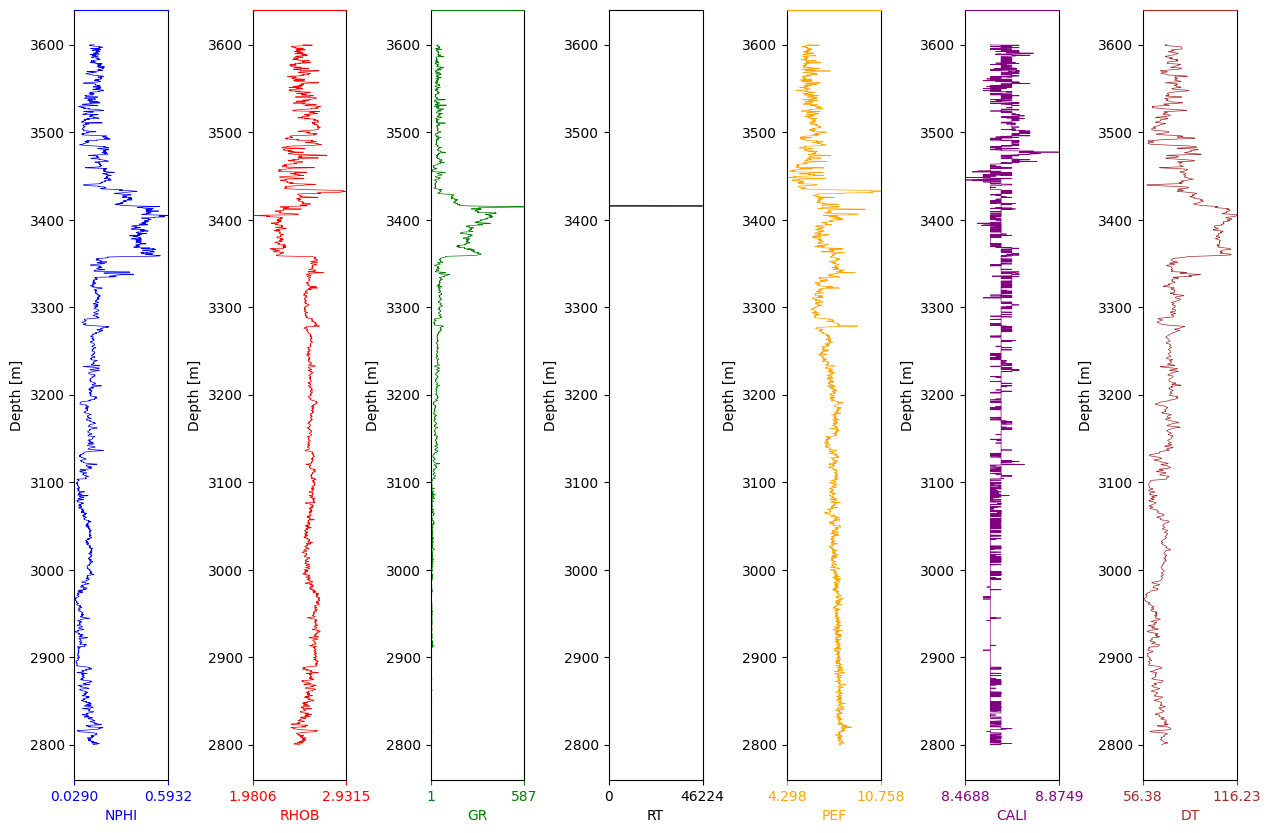

In [12]:
import matplotlib.pyplot as plt

# Set up the plot axes using the number of columns for this put ncols value len(df.columns), set figsize to 15x10
fig, axs = plt.subplots(ncols=len(df.columns), figsize=(15, 10), gridspec_kw=dict(wspace=0.9))

# Define a list of colors for each track
colors = ['blue', 'red', 'green', 'black', 'orange', 'purple', 'brown']

# Loop over all columns in the dataframe to create the log tracks
for i, col in enumerate(df.columns):
    axs[i].plot(df.iloc[:, i], df.index, color=colors[i], linewidth=0.5)
    axs[i].set_xlabel(col)
    axs[i].xaxis.label.set_color(colors[i])
    axs[i].set_xlim(df.iloc[:, i].min(), df.iloc[:, i].max())
    axs[i].set_ylabel("Depth [m]")
    axs[i].tick_params(axis='x', colors=colors[i])
    axs[i].spines["top"].set_edgecolor(colors[i])
    axs[i].title.set_color(colors[i])
    axs[i].set_xticks([df.iloc[:,i].min(), df.iloc[:,i].max()])

## Task 4 Can you notice something strange? What with RT curve? write your comment

I noticed something strange in the **RT (Resistivity)** curve. There are extreme outliers where values exceed 46,000 Ωm, while the rest of the data stays below 100 Ωm. These 'spikes' are likely measurement errors or tool failures. Because of these outliers, the linear scale makes the rest of the curve look like a flat line at zero. To fix this, these values should be capped or removed, and the curve should be viewed on a logarithmic scale.

## Task 5 Check outliers - what is the outlier??

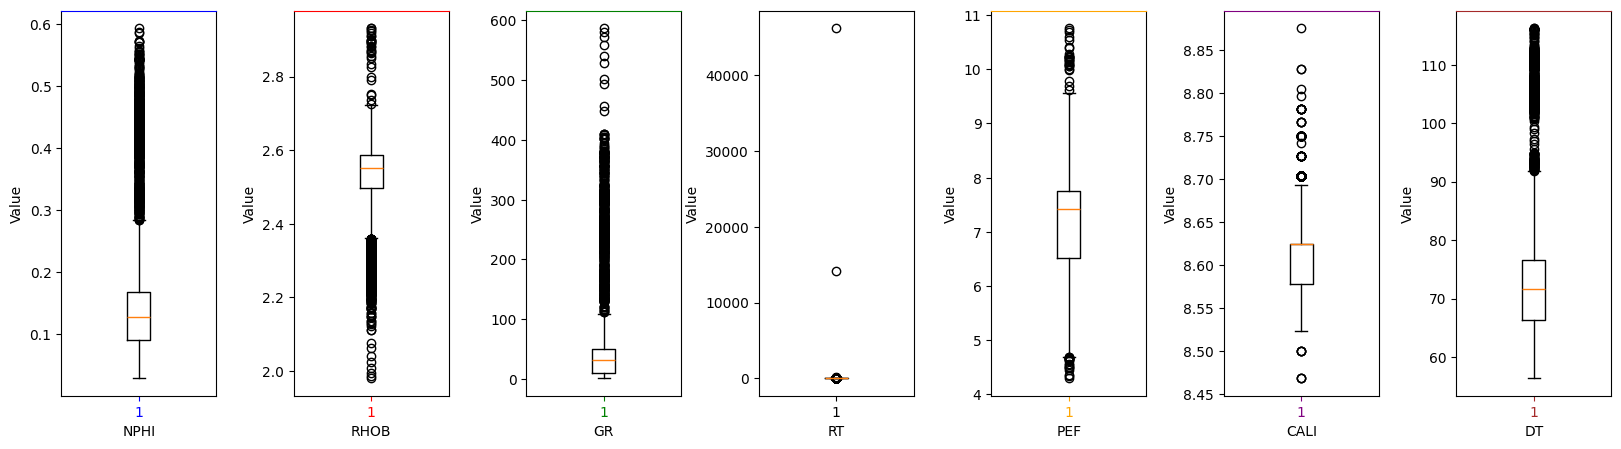

In [13]:
# Set up the plot axes similar as before but use the gig size 20,5
fig, axs = plt.subplots(ncols=len(df.columns), figsize=(20, 5), gridspec_kw=dict(wspace=0.5))

# write a loop function similar as abowe
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col])
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Value")
    axs[i].tick_params(axis='x', colors=colors[i])
    axs[i].spines["top"].set_edgecolor(colors[i])
    axs[i].title.set_color(colors[i])

**What is an outlier?**  
In statistics, an outlier is a data point that differs significantly from other observations in the same dataset. On a boxplot, outliers are easily identified as the individual dots or circles located above the top whisker or below the bottom whisker. These points represent values that are usually more than $1.5 \times$ the Interquartile Range (IQR) away from the edges of the box.  
In our well-log data, outliers often represent:  
- Physical anomalies: Like a very thin, dense layer of rock.  
- Measurement errors: Like the "spikes" we saw in the RT curve in Task 4.  

To handle the extreme outliers in the RT (Resistivity) curve, the best approach is to first "mask" them (replace them with NaN) and then use interpolation to fill the gaps. This ensures that the erroneous spikes don't ruin your statistical analysis or machine learning models.

We need to remove weird high values of RT, but what to do with this observations? We can replace them using interpolation from the nearest samples.

## Task 6 Correct RT curve

In [15]:
import numpy as np

# Replace RT log values greater than 100 with NaN
df.loc[df['RT'] > 100, 'RT'] = np.nan

# Interpolate NaN values based on nearest values
df['RT'] = df['RT'].interpolate(method='nearest')

# Print the resulting DataFrame
print(df)

# Verify the fix: check the new maximum value of RT
print(f"New maximum value for RT: {df['RT'].max()}")

          NPHI    RHOB       GR      RT     PEF    CALI       DT
DEPTH                                                           
2800.0  0.1425  2.4629   3.2562  1.7704  8.0126  8.5782  68.2803
2800.1  0.1416  2.4583   3.2575  1.7734  8.0124  8.6250  68.4759
2800.2  0.1436  2.4548   2.8439  1.8059  8.0316  8.6250  68.6693
2800.3  0.1454  2.4504   2.4479  1.8467  8.0325  8.6249  68.7748
2800.4  0.1509  2.4438   3.0292  1.9006  7.9983  8.5781  68.8805
...        ...     ...      ...     ...     ...     ...      ...
3599.6  0.1289  2.5771  44.3674  2.3147  6.1787  8.5781  70.1850
3599.7  0.1259  2.5490  43.5794  2.3004  5.9839  8.5781  70.3162
3599.8  0.1312  2.5246  44.6774  2.2336  5.8875  8.5781  70.5137
3599.9  0.1365  2.5003  45.4844  2.1827  5.7913  8.5781  70.7711
3600.0  0.1470  2.4950  47.8596  2.1170  5.7226  8.5784  71.3462

[8001 rows x 7 columns]
New maximum value for RT: 31.3151


To clean the dataset, I identified all values in the RT curve exceeding 100 Ωm as measurement errors and replaced them with NaN. I then applied nearest-neighbor interpolation to fill these gaps. This process removes the extreme spikes while maintaining the geological consistency of the log, allowing for a more accurate representative distribution of the resistivity values.

### See if it helped! We will visualize data again

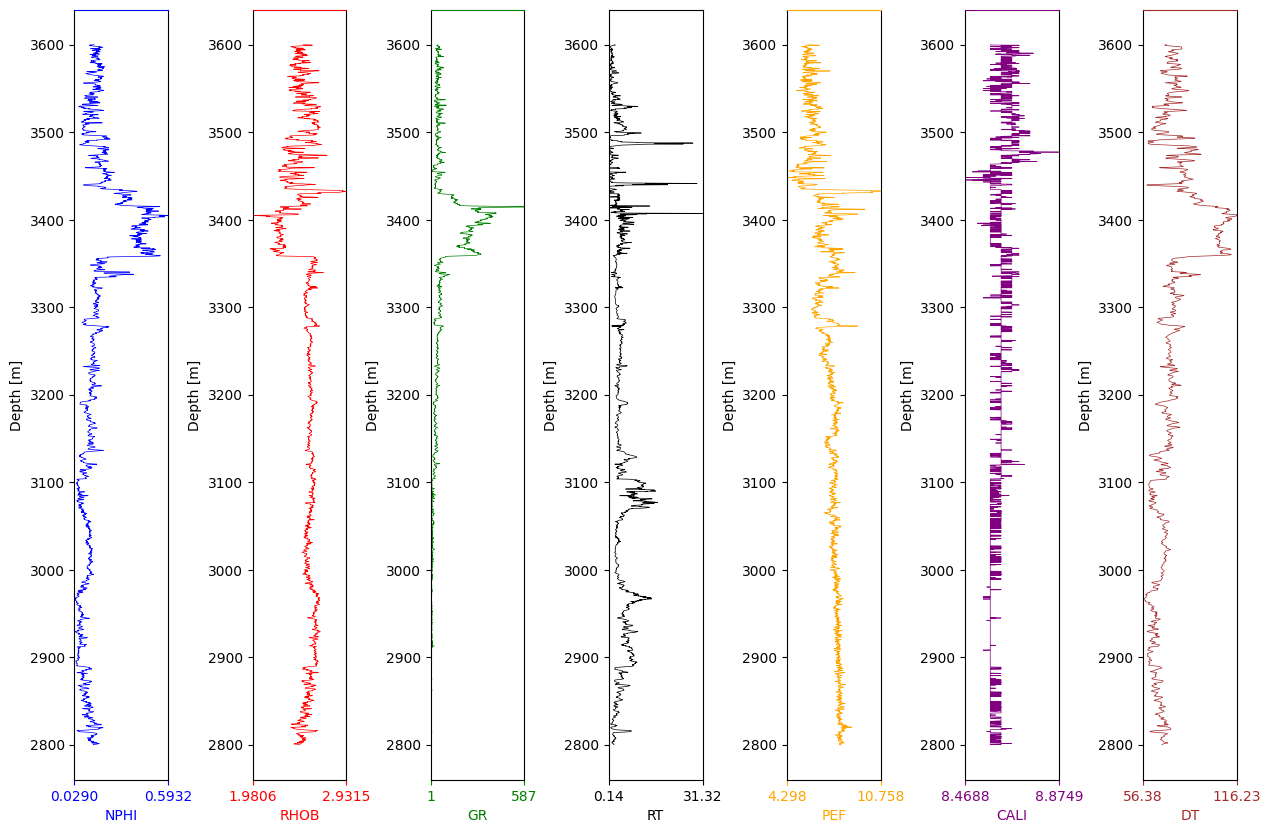

In [17]:
import matplotlib.pyplot as plt

# Re-visualizing the logs after RT cleaning
fig, axs = plt.subplots(ncols=len(df.columns), figsize=(15, 10), gridspec_kw=dict(wspace=0.9))
colors = ['blue', 'red', 'green', 'black', 'orange', 'purple', 'brown']

# Loop over all columns in the dataframe to create the log tracks
for i, col in enumerate(df.columns):
    axs[i].plot(df.iloc[:, i], df.index, color=colors[i], linewidth=0.5)
    axs[i].set_xlabel(col)
    axs[i].xaxis.label.set_color(colors[i])
    axs[i].set_xlim(df.iloc[:, i].min(), df.iloc[:, i].max())
    axs[i].set_ylabel("Depth [m]")
    axs[i].tick_params(axis='x', colors=colors[i])
    axs[i].spines["top"].set_edgecolor(colors[i])
    axs[i].title.set_color(colors[i])
    axs[i].set_xticks([df.iloc[:,i].min(), df.iloc[:,i].max()])

Comparing this to the first plot, the improvement in the RT curve is significant. By capping the values at 100 $\Omega m$ and interpolating, the scale is no longer stretched by the 46,000 $\Omega m$ spikes. We can now clearly see the resistivity variations across different rock layers, which were previously invisible."

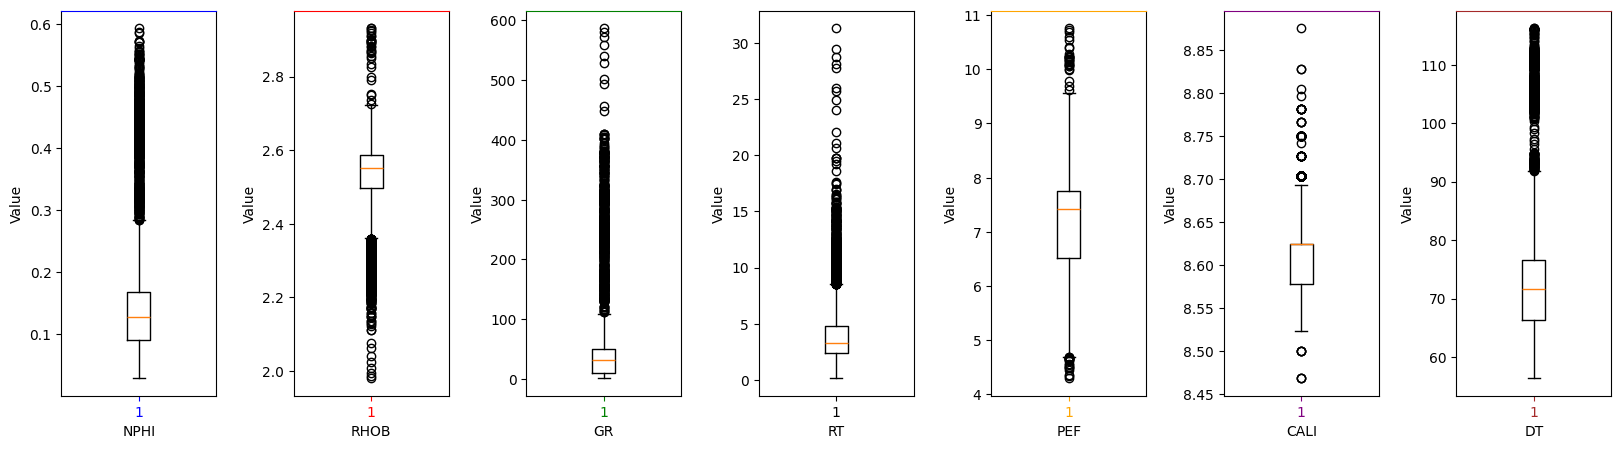

In [18]:
# Re-visualizing the boxplots to check the statistical distribution
fig, axs = plt.subplots(ncols=len(df.columns), figsize=(20, 5), gridspec_kw=dict(wspace=0.5))

# write a loop function similar as abowe
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col])
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Value")
    axs[i].tick_params(axis='x', colors=colors[i])
    axs[i].spines["top"].set_edgecolor(colors[i])
    axs[i].title.set_color(colors[i])

The updated boxplots show that the extreme statistical outliers in the RT log have been eliminated. The 'whisker' range for RT is now much more representative of geological reality. While some outliers remain in other logs (like RHOB or GR), they are likely related to actual lithological changes (like tight streaks or coal beds) rather than tool errors, and thus are safer to keep for the initial clustering phase.

## Task 7 check the outliers visualization using seaborn library

check the seaborn website: https://seaborn.pydata.org/examples/index.html
write in the comment 3 visualizations that you can use in your daily tasks

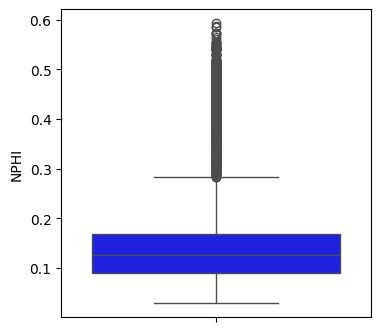

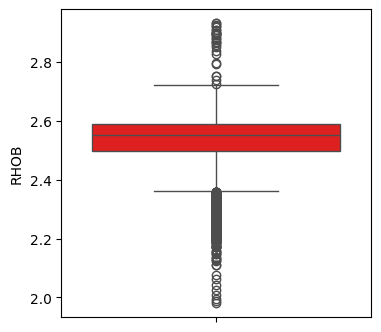

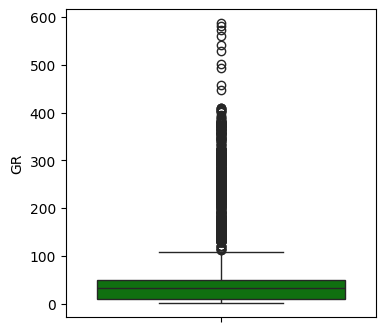

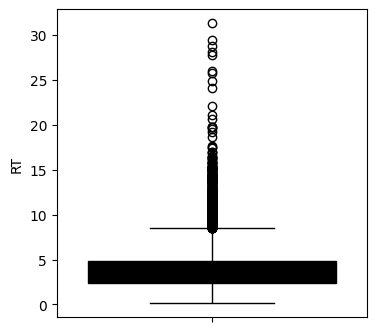

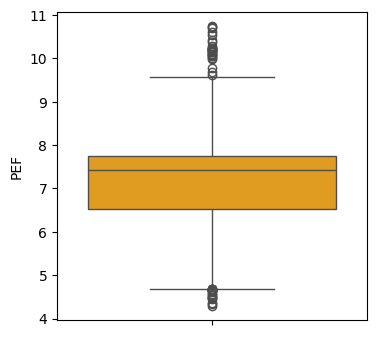

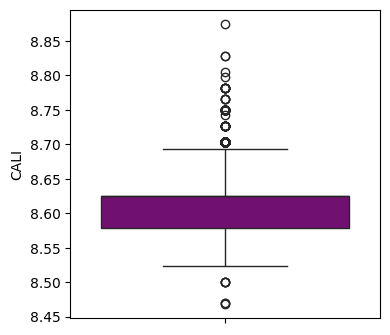

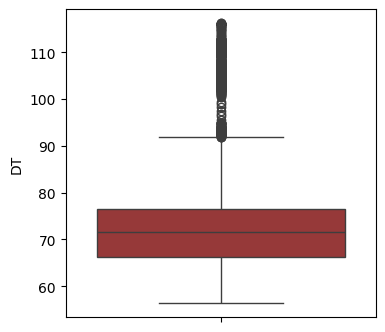

In [19]:
import seaborn as sns

for i, col in enumerate(df.columns):
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.boxplot(y=df[col], color=colors[i], orient='v')



In my daily tasks, I could also use:  
-  **pairplot** for correlation analysis (This is essential for well-log analysis. It creates a matrix of scatter plots for every pair of logs and histograms on the diagonal. It helps us quickly see correlations (e.g., between NPHI and RHOB) and identify multi-dimensional outliers),  
-  **heatmap** for identifying redundant features (Highly useful for plotting Correlation Matrices. It allows us to see at a glance which logs are strongly related, which is crucial for feature selection before clustering or machine learning),  
- **jointplot** for classic petrophysical crossplotting (Excellent for creating Crossplots (like the Neutron-Density crossplot). It shows the relationship between two variables while also displaying their individual distributions (marginal plots) on the sides, making it easy to identify data clusters and trends).

## Task 8 - Remove outliers that are 3 standard deviations from the mean in window of 100 samples

In [20]:
# set window size to 100
window_size = 100

# calculate z-scores for each column using rolling window
z_scores = (df - df.rolling(window_size).mean()) / df.rolling(window_size).std()

# remove rows where any z-score is greater than 3
df_noout = df[(np.abs(z_scores) < 3).all(axis=1)]

# Print the shape to see how many rows were removed
print(f"Original dataframe size: {df.shape}")
print(f"Cleaned dataframe size: {df_noout.shape}")

# print cleaned dataframe
print(df_noout)

Original dataframe size: (8001, 7)
Cleaned dataframe size: (6618, 7)
          NPHI    RHOB       GR      RT     PEF    CALI       DT
DEPTH                                                           
2809.9  0.1427  2.4589   4.2370  2.0991  7.9082  8.6249  70.0120
2810.0  0.1402  2.4615   4.1468  2.0325  7.9031  8.5782  69.9705
2810.1  0.1393  2.4696   4.2389  1.9359  7.9372  8.6015  69.8849
2810.2  0.1348  2.4811   3.6711  1.8266  7.9944  8.5781  69.7992
2810.3  0.1309  2.4924   2.8638  1.7334  8.0531  8.5781  69.7205
...        ...     ...      ...     ...     ...     ...      ...
3599.0  0.1207  2.4931  41.2866  1.4664  5.8496  8.7030  71.5955
3599.1  0.1200  2.5050  42.4855  1.6046  6.0435  8.6718  71.1964
3599.2  0.1240  2.5236  42.9226  1.7066  6.2858  8.6252  70.8162
3599.9  0.1365  2.5003  45.4844  2.1827  5.7913  8.5781  70.7711
3600.0  0.1470  2.4950  47.8596  2.1170  5.7226  8.5784  71.3462

[6618 rows x 7 columns]


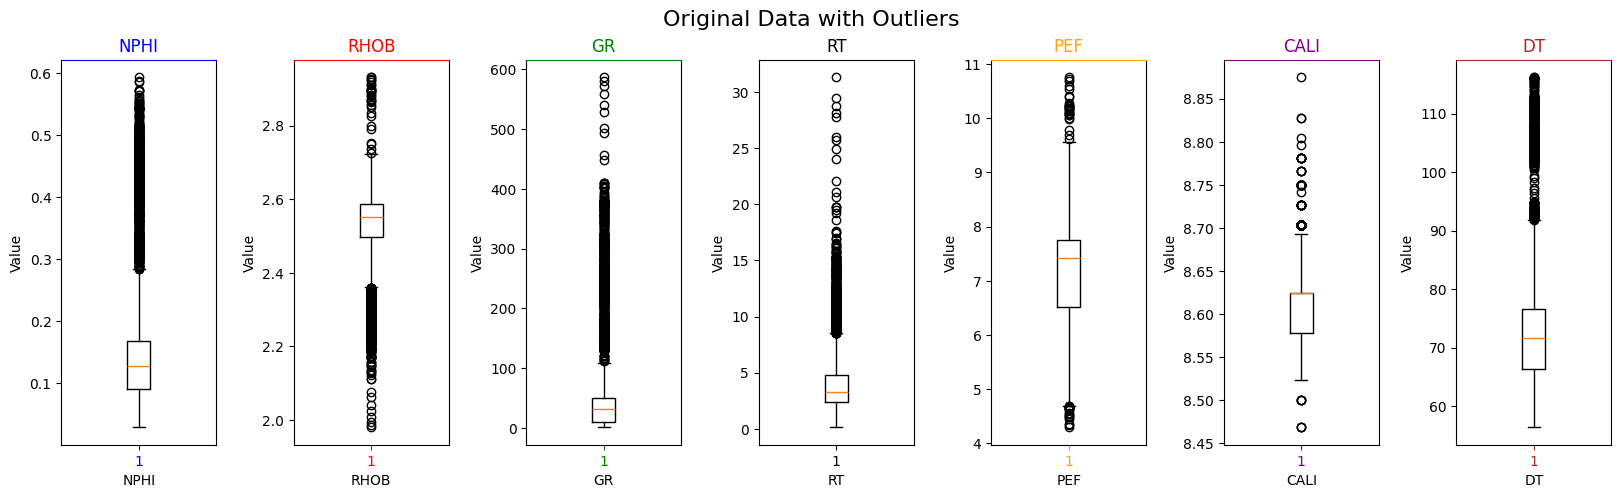

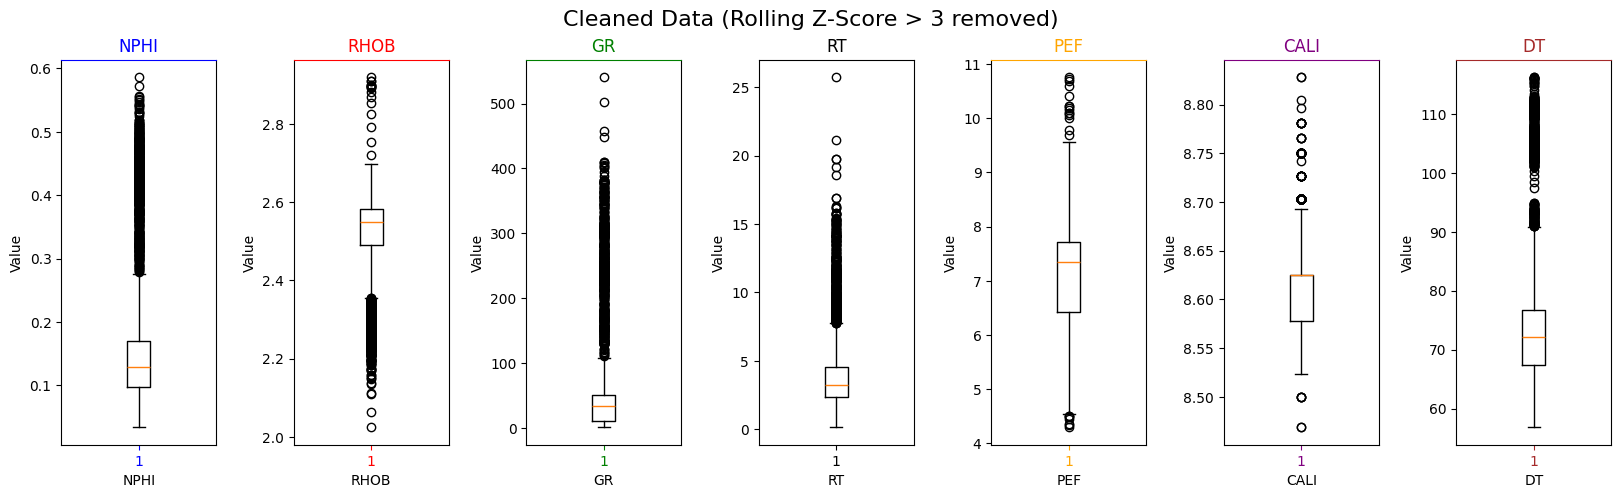

In [21]:
# Set up the plot axes for the original data
fig, axs = plt.subplots(ncols=len(df.columns), figsize=(20,5), gridspec_kw=dict(wspace=0.5))

# Loop for visualization using df dataset
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col].dropna())
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Value")
    # Using the colors list defined in earlier tasks
    axs[i].tick_params(axis='x', colors=colors[i])
    axs[i].spines["top"].set_edgecolor(colors[i])
    axs[i].set_title(col, color=colors[i])

plt.suptitle("Original Data with Outliers", fontsize=16)
plt.show()

# Set up the plot axes for the cleaned data
fig, axs = plt.subplots(ncols=len(df_noout.columns), figsize=(20,5), gridspec_kw=dict(wspace=0.5))

# Loop for visualization using df_noout dataset
for i, col in enumerate(df_noout.columns):
    axs[i].boxplot(df_noout[col].dropna())
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Value")
    axs[i].tick_params(axis='x', colors=colors[i])
    axs[i].spines["top"].set_edgecolor(colors[i])
    axs[i].set_title(col, color=colors[i])

plt.suptitle("Cleaned Data (Rolling Z-Score > 3 removed)", fontsize=16)
plt.show()

# Step 2 - Exploratory Data Analysis
EDA (Exploratory Data Analysis) is the process of analyzing and visualizing data in order to extract insights, patterns, and trends. It is typically one of the first steps in data analysis and is used to gain a better understanding of the data and its characteristics. EDA can help identify outliers, missing values, and any other issues with the data that may need to be addressed before further analysis. It can also help in selecting appropriate statistical methods and models for data analysis. EDA involves using a range of techniques such as histograms, scatter plots, box plots, and correlation matrices to explore the data visually and identify relationships between variables. EDA is an important part of data science and plays a crucial role in the data analysis process.

## Histograms

Histograms are graphical representations of the distribution of data. They display the frequency distribution of a variable by creating a set of contiguous and non-overlapping intervals (or bins) along the range of the variable and then plotting the count or proportion of observations that fall within each bin. By examining a histogram, one can see the central tendency, variability, and shape of the distribution of the data. Additionally, it can also help identify any outliers or unusual patterns in the data. Overall, histograms are useful for understanding the distribution of a variable and gaining insight into the underlying patterns and characteristics of the data.

**Optimal bin size**

**Freedman-Diaconis rule** is a method for determining the bin width of a histogram in statistical data analysis. The rule uses the interquartile range (IQR) of the data and the total number of samples to calculate an appropriate bin width. The bin width is important because it determines the smoothness of the histogram and can affect the interpretation of the data. The Freedman-Diaconis rule aims to create a histogram with sufficient detail to reveal the underlying distribution of the data while avoiding oversmoothing or undersmoothing. It is considered a robust method for determining bin width because it is less sensitive to outliers than other methods such as Sturges' rule or Scott's rule. The Freedman-Diaconis rule has been widely adopted in various fields, including economics, environmental science, and medical research.

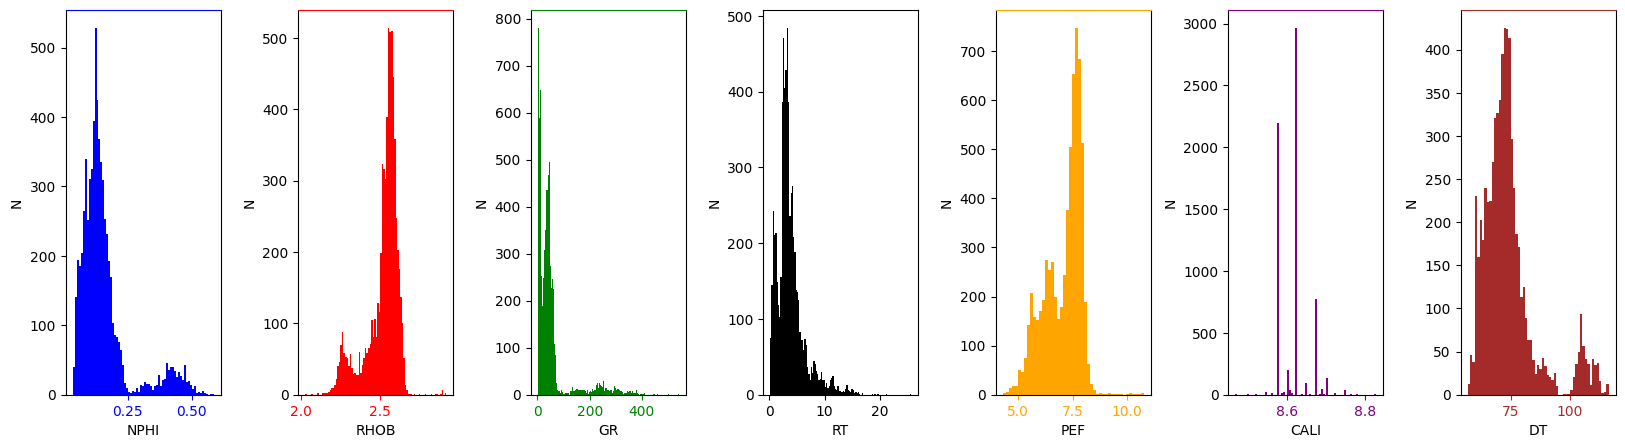

In [23]:
# Set up the plot axes as before
fig, axs = plt.subplots(ncols=len(df_noout.columns), figsize=(20, 5), gridspec_kw=dict(wspace=0.5))

# Define colors if not already defined
colors = ['blue', 'red', 'green', 'black', 'orange', 'purple', 'brown']

# Loop through columns to create histograms
for i, col in enumerate(df_noout.columns):

    # Calculate the bin size using the Freedman-Diaconis rule
    # specify the quartiles
    q75, q25 = np.percentile(df_noout[col], [75, 25])
    # calculate iqr (interquartile range)
    iqr = q75 - q25

    # calculate the width as h equals to double iqr divided by the cube root of the number of observation -> n = len(df[col])
    n = len(df_noout[col])
    h = (2 * iqr) / (n ** (1/3))

    # Avoid division by zero if iqr is 0
    if h == 0: h = 1

    bins = int((df_noout[col].max() - df_noout[col].min()) / h)
    if bins < 1: bins = 10 # Fallback for very small ranges

    axs[i].hist(df_noout[col], bins=bins, color=colors[i])
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("N")
    axs[i].tick_params(axis='x', colors=colors[i])
    axs[i].spines["top"].set_edgecolor(colors[i])
    axs[i].title.set_color(colors[i])

## Pairplot
A pairplot is a graphical tool used in data analysis and visualization that creates pairwise scatterplots and histograms for a given dataset. It is a useful method for exploring the relationship between multiple variables in a dataset. Each scatterplot in the pairplot shows the relationship between two variables in the dataset, while the histograms show the distribution of each variable individually.

By examining the pairplot, we can gain insights into the relationships between variables in the dataset. We can identify variables that are strongly correlated, positively or negatively, as well as variables that are not correlated at all. We can also see the distribution of each variable, including whether they are normally distributed or skewed, and identify any outliers. Pairplots can be useful for identifying potential patterns or trends in the data, as well as for detecting any issues with the data, such as missing or erroneous values. Overall, pairplots are a useful tool for exploratory data analysis and for gaining a better understanding of the relationships between variables in a dataset.

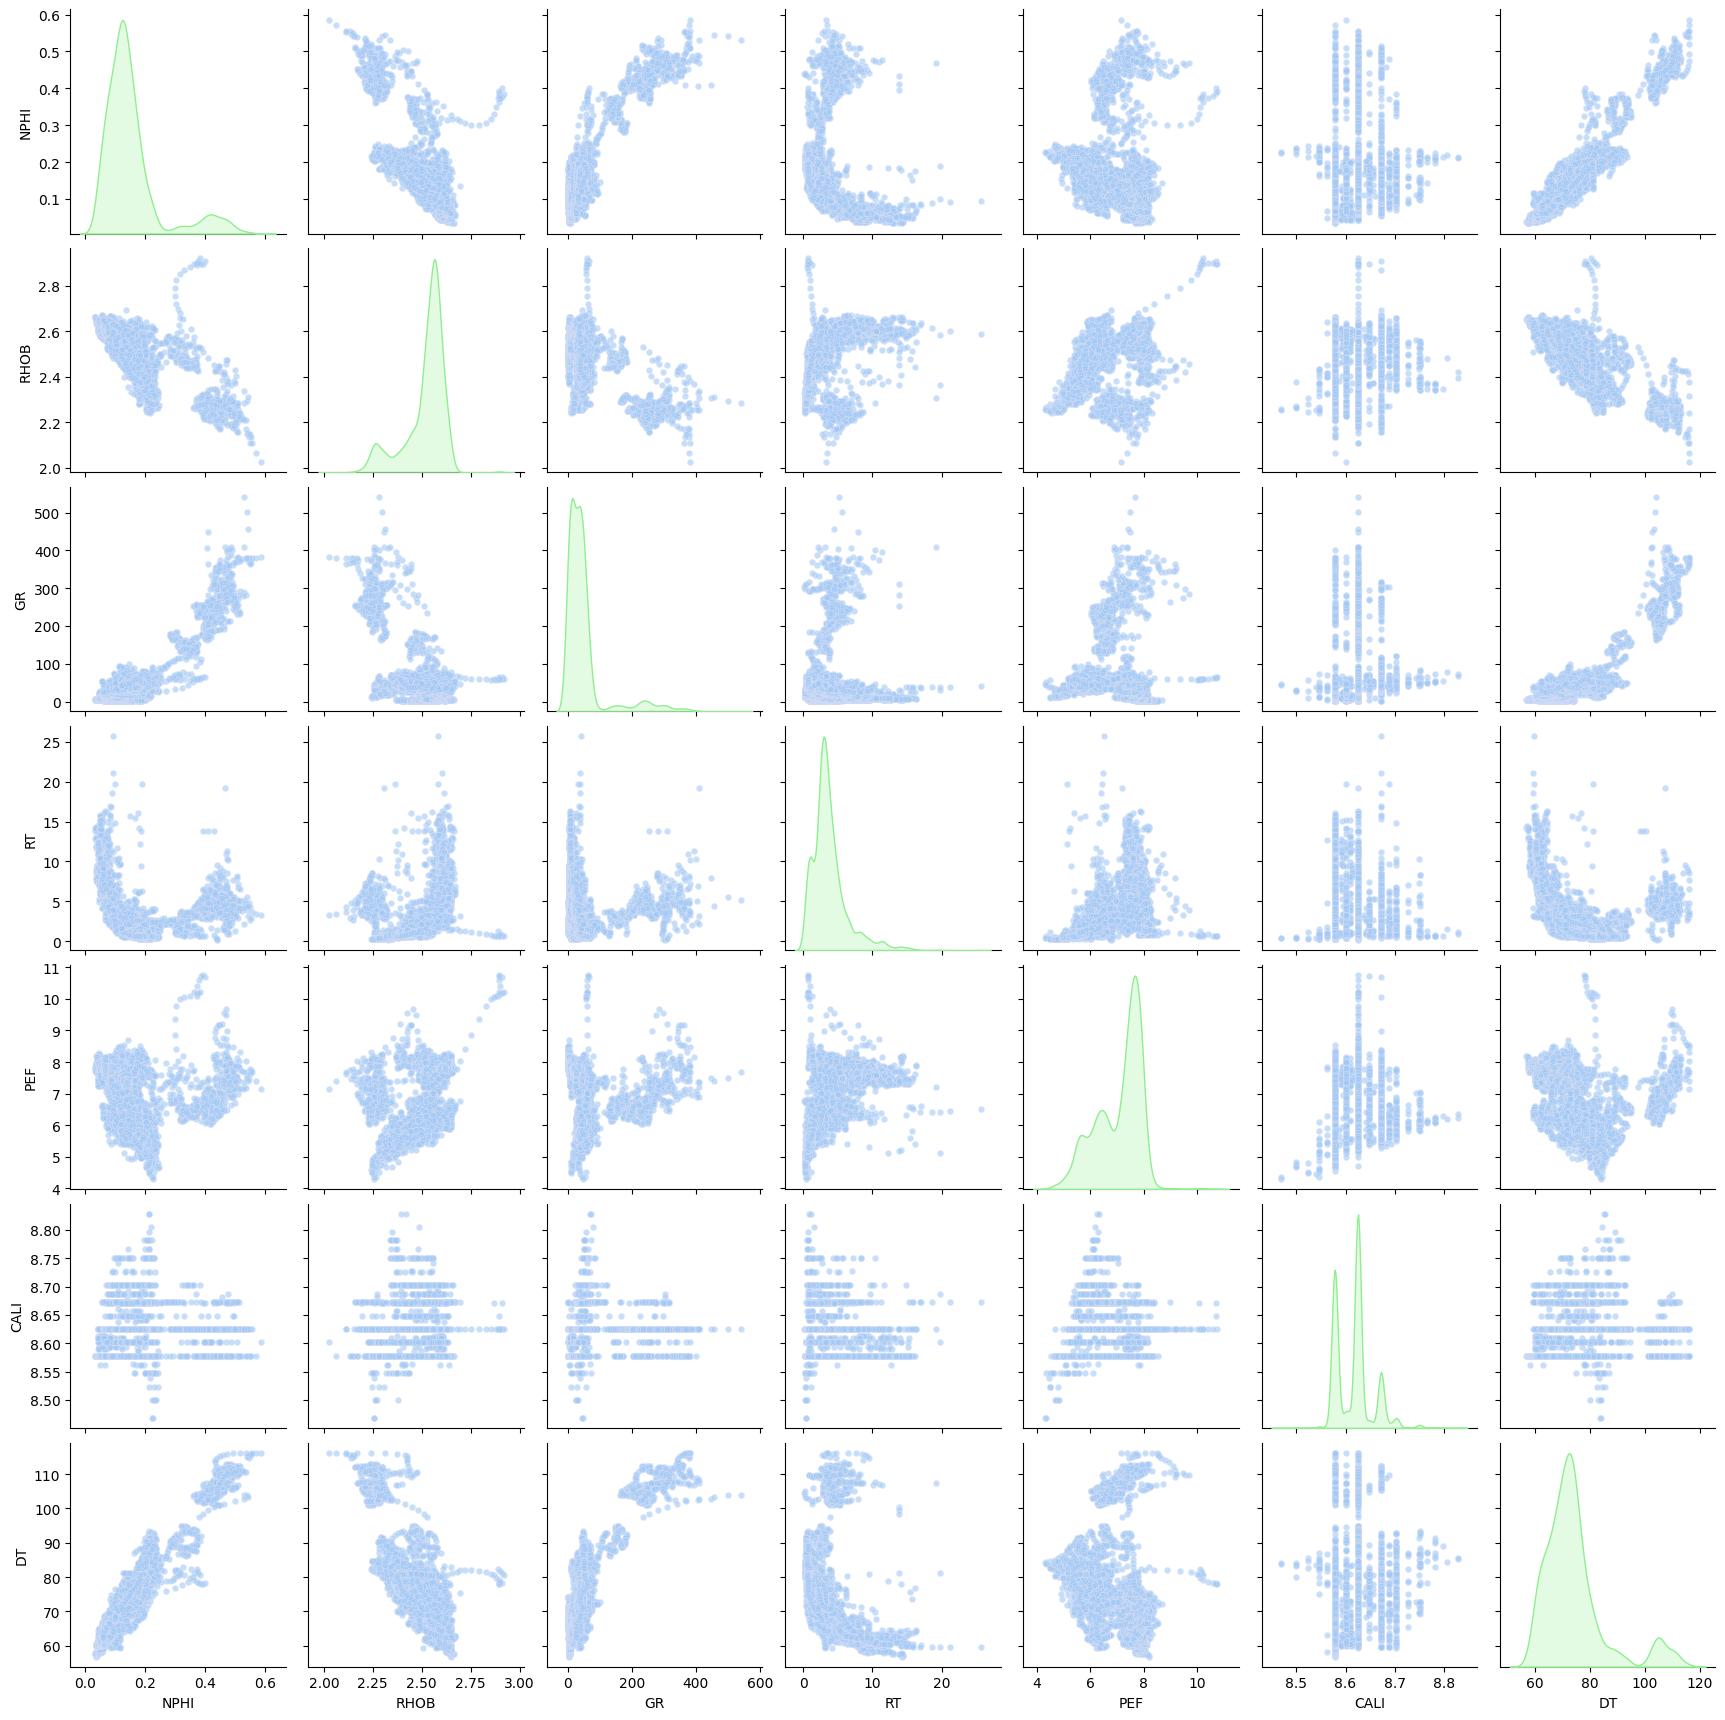

In [24]:
cols = ['NPHI', 'RHOB', 'GR', 'RT', 'PEF', 'CALI', 'DT']

# Define colors for histograms and scatters
hist_color = 'lightgreen'
scatter_color = 'lavender'

# Set the color palette
sns.set_palette("pastel")

# Create pairplot with different colors for histograms and scatters put as vars your column list, and use diag_kind as 'kde', specify size s as 20
sns.pairplot(df_noout, vars=cols, diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 20, 'edgecolor': scatter_color},
             diag_kws={'color': hist_color})

The pairplot reveals that the dataset contains well-defined clusters, particularly in the NPHI-RHOB and GR-NPHI domains. The bimodal nature of the Gamma Ray log suggests a clear distinction between lithologies. However, the skewed distribution of RT confirms the need for logarithmic normalization. These correlations indicate that the data is suitable for cluster-based facies identification, as the physical properties vary consistently with the rock types.

## Correlation matrix

Correlation matrix is a table that displays the correlation coefficients between different variables in a dataset. It is commonly used in statistics and data analysis to identify patterns and relationships between variables.

The correlation coefficient is a statistical measure that ranges from -1 to 1, indicating the strength and direction of the linear relationship between two variables. A value of 1 indicates a perfect positive correlation, meaning that when one variable increases, the other variable increases proportionally. A value of -1 indicates a perfect negative correlation, meaning that when one variable increases, the other variable decreases proportionally. A value of 0 indicates no correlation, meaning that there is no relationship between the variables.

The correlation matrix is a square matrix where the diagonal contains the correlation coefficient between each variable and itself, which is always 1. The upper and lower triangles of the matrix contain the correlation coefficients between each pair of variables, with duplicates reflected across the diagonal. A correlation matrix can be visualized as a heat map, where the color of each cell represents the magnitude of the correlation coefficient. Correlation matrices are commonly used in data analysis, machine learning, and other applications to identify relationships between variables, detect multicollinearity, and perform feature selection.

<Axes: >

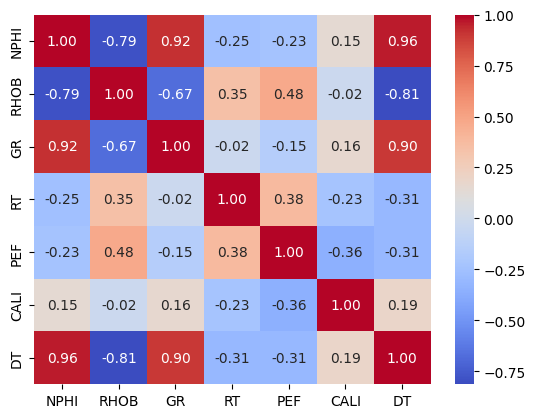

In [25]:
# Define the features to include in the correlation matrix
cols = ['NPHI', 'RHOB', 'GR', 'RT', 'PEF', 'CALI', 'DT']

# Calculate the correlation matrix using the following synthax dataframe[columsn].corr()
corr_matrix = df_noout[cols].corr()

# Set the color palette
sns.set_palette("pastel")

# Create a heatmap of the correlation matrix, set annot to True
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

Strongest Negative Correlation (NPHI vs. RHOB):The heatmap shows a strong negative correlation (typically between $-0.7$ and $-0.9$) between Neutron Porosity and Bulk Density. This is the "Gold Standard" in petrophysics. As the rock becomes more porous (NPHI increases), its total density (RHOB) decreases because the heavy rock matrix is being replaced by lighter fluids (water or oil).  

Strong Positive Correlation (NPHI vs. DT):There is a high positive correlation between NPHI and Sonic Travel Time (DT). This makes physical sense: sound waves travel slower (higher DT) in porous, fluid-filled media compared to solid rock. This confirms that both tools are responding consistently to the formation's porosity.  

The "Shale" Indicator (GR vs. NPHI/DT):Gamma Ray (GR) shows a positive correlation with both NPHI and DT. In the North Sea (Volve field), shales tend to have higher Gamma Ray readings, higher neutron porosity (due to chemically bound water in clay), and are slower/less dense than clean sandstones.  

RT (Resistivity) Independence:You will notice that RT has the lowest correlation coefficients with most other logs (often near $0.1$ or $0.2$). This is expected because Resistivity is a fluid indicator, not just a lithology indicator. While GR or RHOB tell us about the rock type, RT tells us if there are hydrocarbons present, which can vary independently of the rock matrix.

CALI (Caliper) Correlation:The Caliper log (CALI) shows its strongest relationship with RHOB. A high correlation here often warns us of borehole washouts. When the hole is oversized (high CALI), the density tool (RHOB) loses contact with the wall, leading to artificially low density readings.  

The correlation matrix confirms the physical consistency of our dataset. The strong NPHI-RHOB-DT relationships indicate high-quality porosity data, while the distinct behavior of GR suggests it will be a primary feature for lithology separation. The independence of the RT log suggests it provides unique information about the fluid content that other logs do not capture. These insights justify using all seven parameters as features for the K-Means clustering algorithm.

# Step 3 - data normalization

Data normalization, also known as feature scaling, is the process of transforming data into a common scale or range in order to facilitate data analysis and improve the performance of machine learning algorithms. Normalization is important because many machine learning algorithms are sensitive to the scale and distribution of input features, and may perform poorly or inaccurately if the features are not on a similar scale.

Normalization involves rescaling the features of a dataset to have a mean of 0 and a standard deviation of 1, or scaling the features to a range between 0 and 1. The normalization method used depends on the specific data and the requirements of the analysis or algorithm being used. Common methods of normalization include Min-Max scaling, Z-score normalization, and Log transformation.

Min-Max scaling involves scaling the features to a range between 0 and 1, where the minimum value of the feature is transformed to 0 and the maximum value is transformed to 1. Z-score normalization involves transforming the features so that they have a mean of 0 and a standard deviation of 1, which can be accomplished by subtracting the mean from each value and then dividing by the standard deviation. Log transformation is another normalization technique used for data that is highly skewed or has a wide range of values, and involves applying a logarithmic function to the data to transform it into a more normal distribution.

Overall, data normalization is an important preprocessing step in data analysis and machine learning, as it can help to improve the accuracy and performance of models and algorithms, reduce overfitting, and ensure that features are on a similar scale.


## 3.1 - Transform Resitivity Log to log scale

Resistivity data in well logs is typically measured in ohm-meters, and the values can span several orders of magnitude, making it difficult to visualize and analyze the data directly. To address this issue, resistivity data is often transformed using a logarithmic scale, which compresses the data into a more manageable range.

The logarithmic scale is a nonlinear scale that compresses large values into a smaller range, while expanding small values. This allows for a more accurate visualization of the data and makes it easier to identify patterns and trends. In particular, the use of logarithmic scales is useful for resistivity data because the range of resistivity values encountered in well logs can be very large, spanning several orders of magnitude.

In [27]:
df_noout['RT'] = np.log10(df_noout['RT'])

/tmp/ipython-input-3476924017.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_noout['RT'] = np.log10(df_noout['RT'])


In [28]:
#check data
df_noout['RT']

,RT
DEPTH,
2809.9,0.322033
2810.0,0.308031
2810.1,0.286883
2810.2,0.261643
2810.3,0.238899
...,...
3599.0,0.166252
3599.1,0.205367
3599.2,0.232132


## 3.2 - Transform data with skewed distribution
The power transform with Yeo-Johnson method is a data transformation technique used to normalize a dataset that has a skewed distribution. It is a variant of the Box-Cox transformation, which is used to normalize data that has a positive skew.

The Yeo-Johnson method is a modified version of the Box-Cox transformation that can be applied to both positively and negatively skewed data, as well as data that includes zero or negative values. It works by applying a power transformation to the data that varies based on the value of a lambda parameter, which is estimated from the data.

The Yeo-Johnson method is implemented in the PowerTransformer class of the scikit-learn library in Python. It can be used to transform a pandas DataFrame or numpy array to have a more normal distribution, which can be useful for machine learning models that assume a normal distribution of the data.

In [29]:
from IPython.display import Image
Image(url="https://i.postimg.cc/sDRksm7T/2.png")

In [30]:
#import necessary libraries
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
import pandas as pd

#define the columns to be transformed
numeric_features = ['NPHI', 'RHOB', 'GR', 'RT', 'PEF', 'CALI', 'DT']

#define the transformation pipeline using PowerTransformer with Yeo-Johnson method and standardization
numeric_transformer = Pipeline(steps=[
('scaler', PowerTransformer(method='yeo-johnson', standardize=True))
])

#define the ColumnTransformer to apply the transformation pipeline to the numeric features
preprocessor = ColumnTransformer(transformers=[
('num', numeric_transformer, numeric_features)
])

#fit and transform the data using the preprocessor
transformed_data = preprocessor.fit_transform(df_noout[numeric_features])

#convert the transformed data to a DataFrame with column names and add the depth column from the original data
transformed_data = pd.DataFrame(transformed_data, columns=numeric_features)
transformed_data['DEPTH'] = df_noout.reset_index()['DEPTH']
transformed_data = transformed_data.set_index('DEPTH')

In [31]:
# Verify the result
print(transformed_data.head())
print(transformed_data.describe().round(2))

            NPHI      RHOB        GR        RT       PEF          CALI  \
DEPTH                                                                    
2809.9  0.205930 -0.745286 -1.564246 -0.607747  1.055451  8.187895e-16   
2810.0  0.167616 -0.721726 -1.581017 -0.649999  1.047754 -3.830269e-15   
2810.1  0.153634 -0.647008 -1.563896 -0.712988  1.099386 -1.471046e-15   
2810.2  0.082195 -0.537420 -1.674785 -0.786870  1.186874 -3.830269e-15   
2810.3  0.018157 -0.425602 -1.859007 -0.852242  1.277809 -3.830269e-15   

              DT  
DEPTH             
2809.9 -0.211915  
2810.0 -0.217361  
2810.1 -0.228633  
2810.2 -0.239972  
2810.3 -0.250432  
          NPHI     RHOB       GR       RT      PEF    CALI       DT
count  6618.00  6618.00  6618.00  6618.00  6618.00  6618.0  6618.00
mean     -0.00    -0.00    -0.00    -0.00     0.00    -0.0     0.00
std       1.00     1.00     1.00     1.00     1.00     0.0     1.00
min      -2.48    -2.77    -2.49    -2.91    -2.50    -0.0    -2.83
25%     

## DRAW Pairplot using transformed data


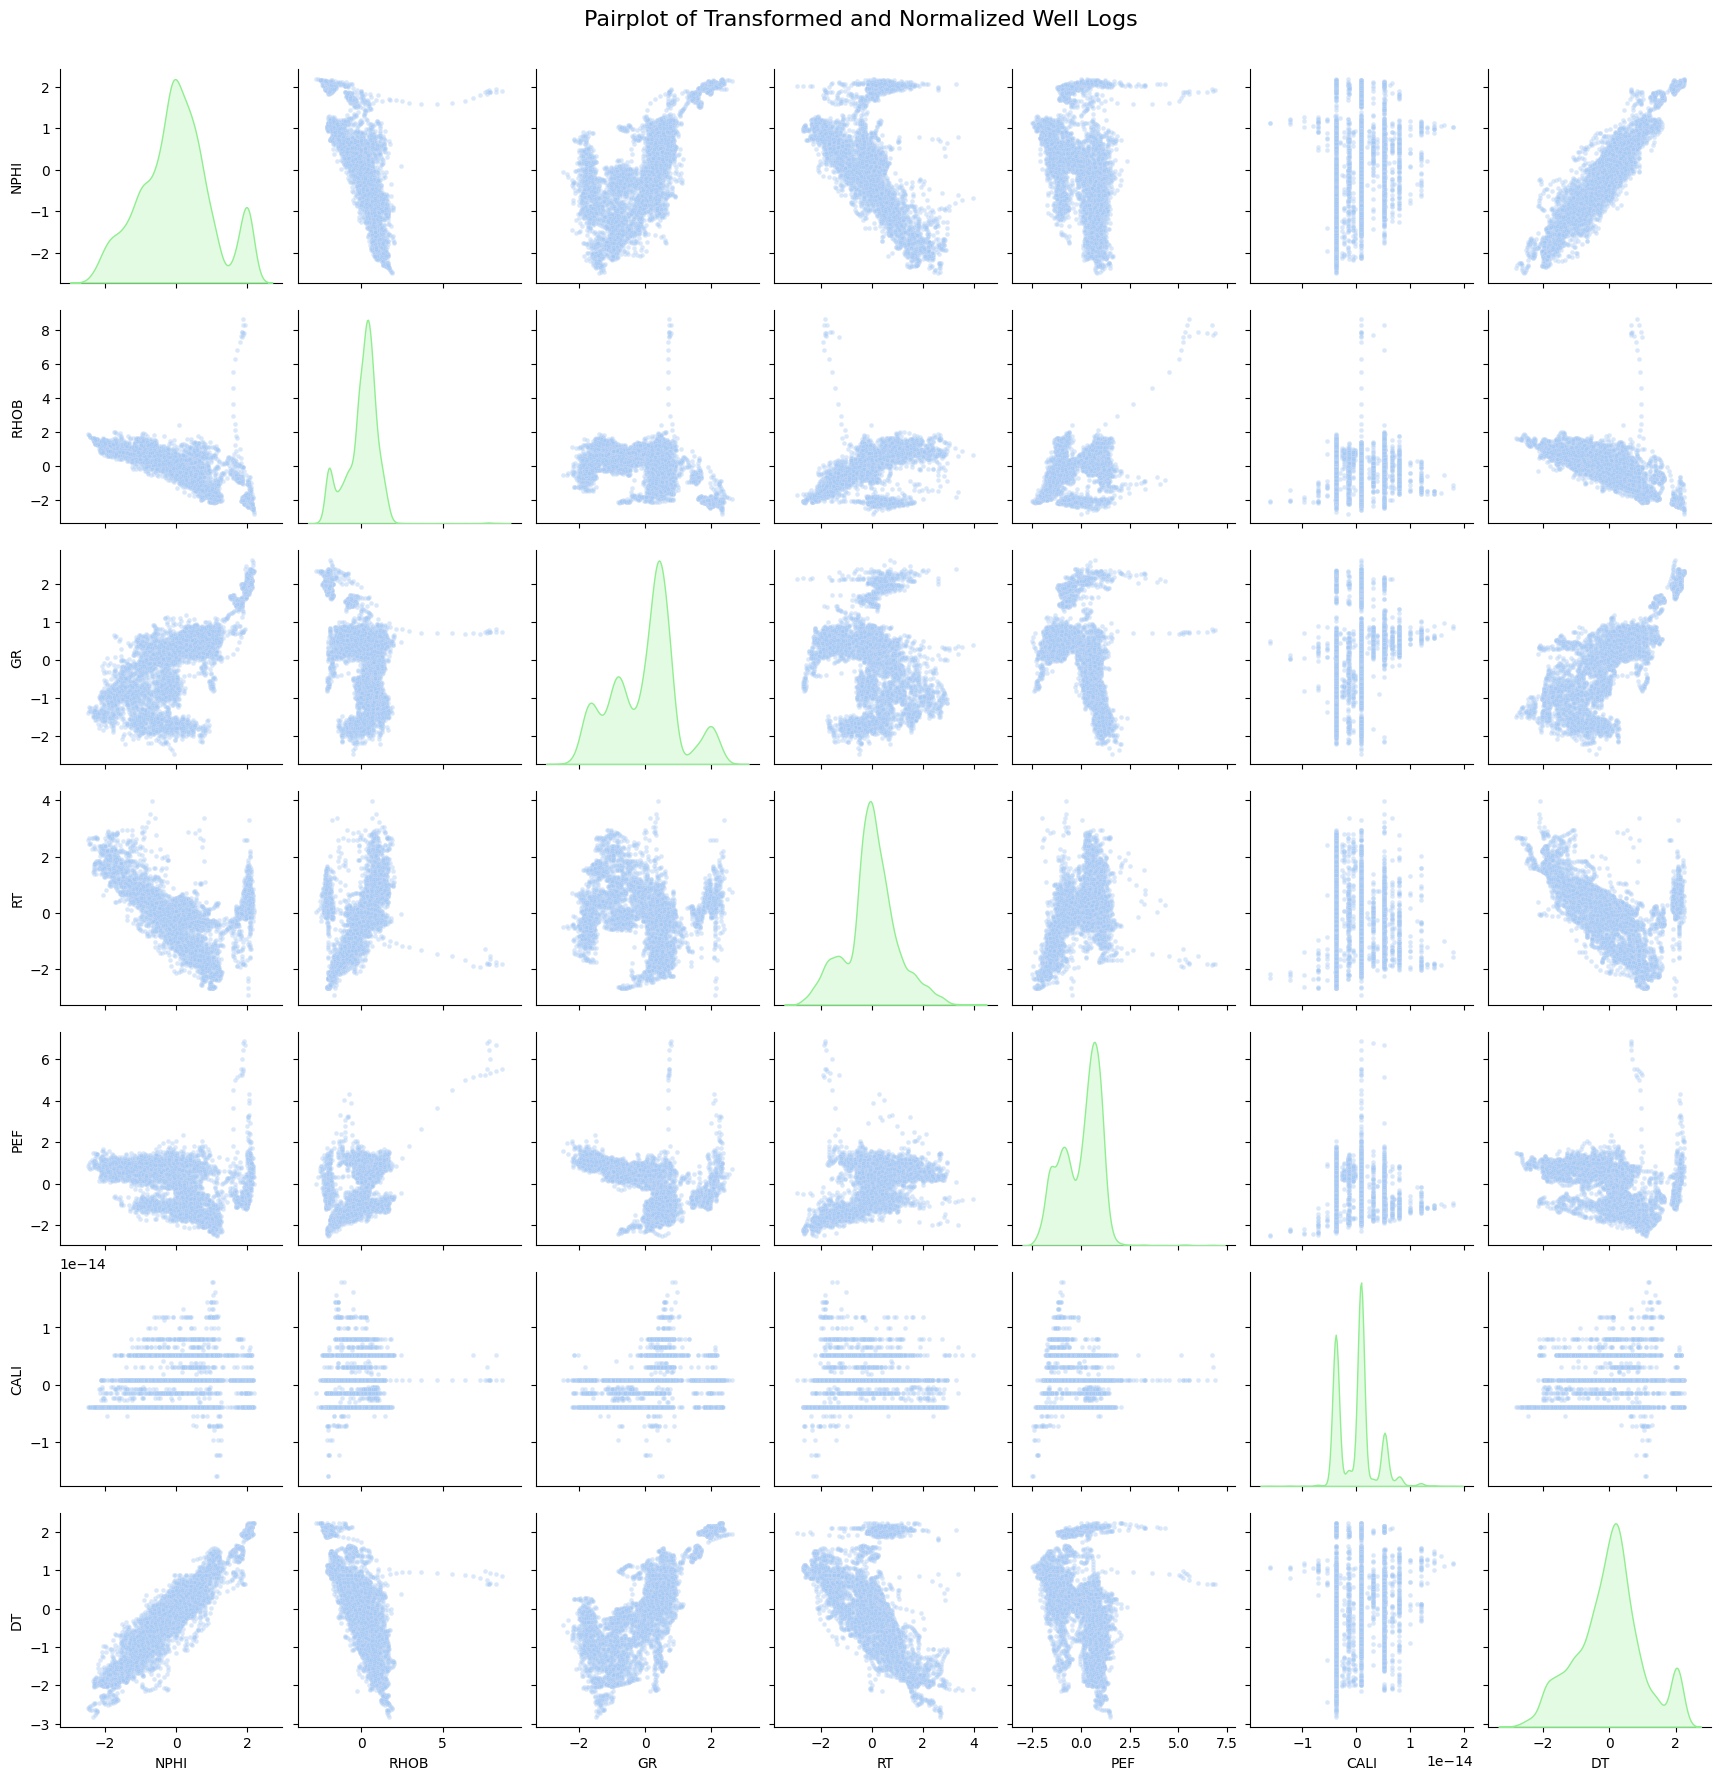

In [32]:
# Columns to include in the plot
cols = ['NPHI', 'RHOB', 'GR', 'RT', 'PEF', 'CALI', 'DT']

# Define the visual style
hist_color = 'lightgreen'
scatter_color = 'lavender'
sns.set_palette("pastel")

# Create pairplot with transformed data
# diag_kind='kde' shows the smoothed distribution
pair_plot = sns.pairplot(transformed_data, vars=cols, diag_kind='kde',
                         plot_kws={'alpha': 0.4, 's': 10, 'edgecolor': scatter_color},
                         diag_kws={'color': hist_color})

pair_plot.fig.suptitle('Pairplot of Transformed and Normalized Well Logs', y=1.02, fontsize=16)
plt.show()

## DRAW boxplots using transformed data


/tmp/ipython-input-3706390454.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


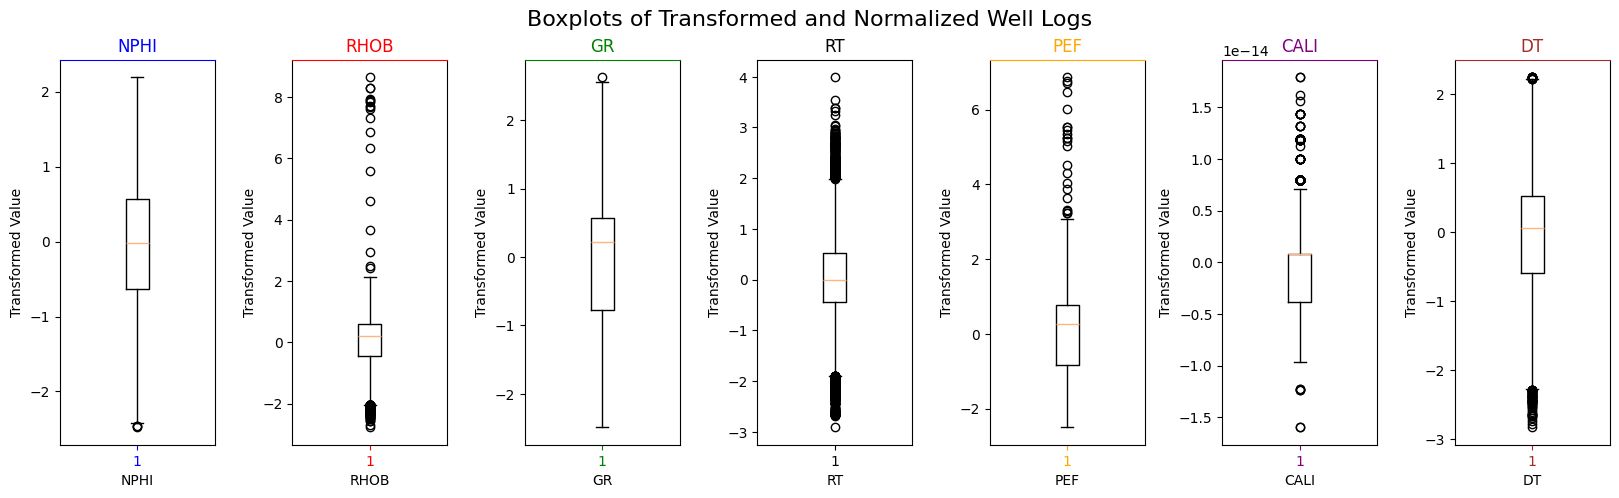

In [33]:
cols = ['NPHI', 'RHOB', 'GR', 'RT', 'PEF', 'CALI', 'DT']
colors = ['blue', 'red', 'green', 'black', 'orange', 'purple', 'brown']

fig, axs = plt.subplots(ncols=len(cols), figsize=(20, 5), gridspec_kw=dict(wspace=0.5))

for i, col in enumerate(cols):
    axs[i].boxplot(transformed_data[col].dropna())
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Transformed Value")

    axs[i].tick_params(axis='x', colors=colors[i])
    axs[i].spines["top"].set_edgecolor(colors[i])
    axs[i].set_title(col, color=colors[i])

plt.suptitle("Boxplots of Transformed and Normalized Well Logs", fontsize=16)
plt.tight_layout()
plt.show()

General Observations on Data Preparation:  
- Data Quality Improvement:Initial visualizations revealed that the raw data contained significant noise, particularly "spikes" in the Resistivity (RT) log reaching non-physical values (>46,000 $\Omega m$). The manual capping at 100 $\Omega m$ combined with nearest-neighbor interpolation successfully recovered the geological signal without distorting the surrounding data.  
- Effectiveness of the Rolling Z-Score:The application of a rolling window (100 samples) to remove outliers was superior to a global filter. It allowed the removal of transient tool noise while respecting the natural changes in physical properties occurring at different depths (stratigraphic transitions).  
- Statistical Normalization:The Yeo-Johnson Power Transformation proved to be highly effective. Looking at the final pairplots and histograms, the features now follow a near-normal (Gaussian) distribution. This is a critical requirement for the K-Means algorithm, which uses Euclidean distance; without this step, logs with larger scales (like Gamma Ray) would have disproportionately influenced the clustering results.  
- Feature Consistency:The final boxplots of the transformed data show that all seven features are now "centered" around 0 with a similar spread (standard deviation of ~1). This "level playing field" ensures that the upcoming clustering process will identify facies based on the combined physical signature of the rock, rather than being biased by the units of measurement (e.g., $m/s$ vs. $g/cm^3$).  
- Conclusion for ML Readiness:The dataset is now clean, normalized, and structurally consistent. The relationships observed in the correlation matrix (e.g., the strong NPHI-RHOB porosity trend) have been preserved through the transformation process. The data is now fully prepared for Step 5: K-Means Clustering to identify electrofacies.

# Step 4 - final outlier removal using ML

**The Isolation Forest** algorithm is a type of computer program that helps find "outliers" in data. Outliers are data points that are very different from all the other data points. For example, imagine you have a list of test scores from your class, and one student got a score that is much higher or lower than everyone else. That student's score would be an outlier.

The Isolation Forest algorithm works by putting each data point in a "tree". Each tree has branches that divide the data into smaller and smaller groups. The algorithm keeps dividing the data until each point is in its own group, or until a certain number of groups have been made. This is like playing a game of "guess who" where you try to guess a character by asking yes-or-no questions, and keep dividing the characters into smaller groups until you know who the character is.

Once the data points are divided into groups, the algorithm looks at how many times each point was in a group with other points. If a point was in a group with other points many times, it is not an outlier. But if a point was in a group by itself many times, it is an outlier.

The Isolation Forest algorithm can be useful for finding outliers in data, which can be helpful in many different fields like finance, healthcare, and more.

In [34]:
from IPython.display import Image
Image(url="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*D78QLbcwXesymhquuofnOg.png")

In [35]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

In [36]:
# Define the numerical columns in your DataFrame
numeric_cols = ['NPHI', 'RHOB', 'GR', 'RT', 'PEF', 'CALI', 'DT']

In [37]:
# Instantiate the isolation forest for each column separately
isos = {}
for col in numeric_cols:
    iso = IsolationForest(n_estimators=100, max_samples='auto', contamination=float(0.05), random_state=42)
    iso.fit(transformed_data[col].values.reshape(-1, 1))
    isos[col] = iso


In [38]:
# Replace the outliers with the mean of neighboring values for each column in a single loop
for col in numeric_cols:
    outliers = isos[col].predict(transformed_data[col].values.reshape(-1, 1)) == -1
    values = transformed_data[col].values
    mean = np.mean(values[~outliers])
    for i in range(len(values)):
        if outliers[i]:
            # Replace outlier with the mean of neighboring values
            if i == 0:
                values[i] = values[i+1]
            elif i == len(values)-1:
                values[i] = values[i-1]
            else:
                values[i] = (values[i-1] + values[i+1])/2
    transformed_data[col] = values

In [39]:
# Fill any remaining NaN values with interpolated values
transformed_data[numeric_cols] = transformed_data[numeric_cols].interpolate()


In [40]:
# Print the resulting DataFrame without outliers
print(transformed_data)

            NPHI      RHOB        GR        RT       PEF          CALI  \
DEPTH                                                                    
2809.9  0.205930 -0.745286 -1.564246 -0.607747  1.055451  8.187895e-16   
2810.0  0.167616 -0.721726 -1.581017 -0.649999  1.047754 -3.830269e-15   
2810.1  0.153634 -0.647008 -1.563896 -0.712988  1.099386 -1.471046e-15   
2810.2  0.082195 -0.537420 -1.674785 -0.786870  1.186874 -3.830269e-15   
2810.3  0.018157 -0.425602 -1.859007 -0.852242  1.277809 -3.830269e-15   
...          ...       ...       ...       ...       ...           ...   
3599.0 -0.159180 -0.418538  0.391791 -1.053360 -1.395774  4.805184e-15   
3599.1 -0.171897 -0.295911  0.417180 -0.946528 -1.216829  5.204170e-15   
3599.2 -0.100195 -0.094388  0.426257 -0.871470 -0.979093  8.604228e-16   
3599.9  0.109486 -0.344918  0.477658 -0.555989 -1.447658 -3.830269e-15   
3600.0  0.270070 -0.399279  0.522775 -0.596548 -1.507675 -3.816392e-15   

              DT  
DEPTH             

## DRAW boxplots for transformed_data


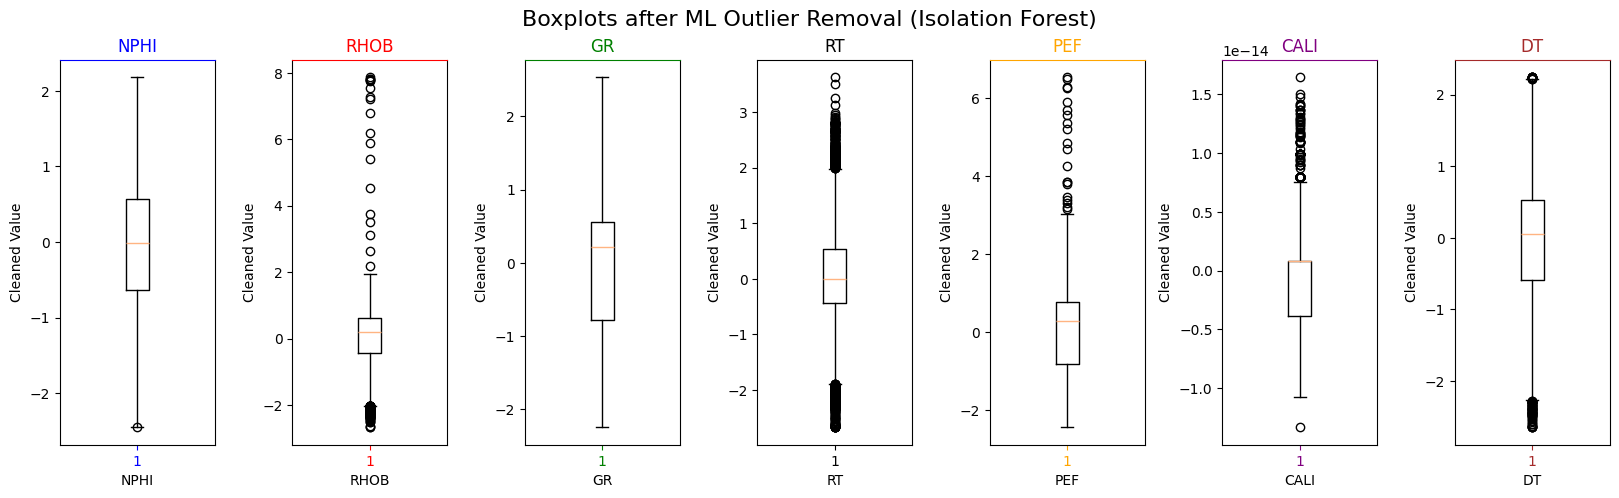

In [41]:
fig, axs = plt.subplots(ncols=len(numeric_cols), figsize=(20, 5), gridspec_kw=dict(wspace=0.5))
colors = ['blue', 'red', 'green', 'black', 'orange', 'purple', 'brown']

for i, col in enumerate(numeric_cols):
    axs[i].boxplot(transformed_data[col].dropna())
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Cleaned Value")
    axs[i].tick_params(axis='x', colors=colors[i])
    axs[i].spines["top"].set_edgecolor(colors[i])
    axs[i].set_title(col, color=colors[i])

plt.suptitle("Boxplots after ML Outlier Removal (Isolation Forest)", fontsize=16)
plt.show()

# Step 5 - Facies analysis
Facies analysis from well logs is an important task in petroleum geology. It involves identifying and classifying the different rock types, or facies, encountered in a well. Traditionally, this has been done by geologists through visual inspection of the well logs. However, with the rise of machine learning techniques, it has become possible to automate this process.

One common approach to facies analysis is to use unsupervised clustering algorithms, such as K-means or hierarchical clustering, to group similar sections of the well log together. The goal is to identify natural groupings, or clusters, of log responses that correspond to different facies. Once the clusters have been identified, the geologist can assign each cluster to a specific facies based on their knowledge of the local geology.

To perform facies analysis using machine learning clustering, several well logs are typically collected and pre-processed. The logs are usually normalized and scaled to make them comparable, and any missing data is imputed or removed. Features, such as gamma-ray, resistivity, and porosity, are extracted from the logs and used as inputs to the clustering algorithm.

Once the features have been extracted, a clustering algorithm is applied to group the sections of the well log that have similar responses. The algorithm assigns each section to a cluster, which can be visualized on a plot. The plot can help identify any clear patterns or trends in the data and help the geologist make sense of the clustering results.

The next step is to assign each cluster to a specific facies. This is done by comparing the clustering results to the geological knowledge of the area. The geologist may use other data sources, such as core samples or outcrop data, to help identify the facies associated with each cluster.

Once the clusters have been assigned to facies, the results can be used to create a facies log. This log can be used to interpret the geology of the well and to help identify potential hydrocarbon reservoirs or other geological features.

In [42]:
from IPython.display import Image
Image(url="https://interviewquery-cms-images.s3-us-west-1.amazonaws.com/ac5da238-25ab-48ef-839a-407a7b76a167.jpg")

## K-means
is a type of unsupervised learning algorithm used for clustering data points into different groups or clusters based on the similarity of the data points. The algorithm works by iteratively assigning each data point to the nearest cluster center, and then computing the new cluster centers based on the mean of the assigned points. This process is repeated until the cluster centers no longer move significantly.

The algorithm requires the user to specify the number of clusters beforehand. The objective of the algorithm is to minimize the sum of squared distances between each data point and its assigned cluster center, which is also known as the Within-Cluster-Sum-of-Squares (WCSS) metric.

The k-means algorithm can be divided into three main steps:

1. **Initialization:** The algorithm randomly selects k data points to act as initial cluster centers.

2. **Assignment:** Each data point is assigned to the nearest cluster center based on the Euclidean distance between the point and the center.

3. **Update:** The mean of the data points assigned to each cluster is computed, and this value is used as the new cluster center.

These three steps are repeated iteratively until the cluster centers no longer move significantly, or a maximum number of iterations is reached. The final output of the algorithm is the cluster assignments of each data point.

One of the main advantages of the k-means algorithm is its simplicity and scalability, which allows it to handle large datasets efficiently. However, the algorithm is sensitive to the initial placement of the cluster centers, and may converge to suboptimal solutions. In addition, the algorithm is not effective when dealing with non-linearly separable data. Nonetheless, k-means is widely used in various applications such as image segmentation, market segmentation, and anomaly detection.

In [43]:
from IPython.display import Image
Image(url="https://ds055uzetaobb.cloudfront.net/brioche/uploads/y4KGN92h7r-screen-shot-2016-05-05-at-43007-pm.png?width=2000")

In [44]:
from sklearn.cluster import KMeans

# define features using cols
X = transformed_data[cols]

In [45]:
#define model set n_clusters to 10
model = KMeans(n_clusters=10, n_init=10, random_state=42)

In [46]:
# fit the model to data
y = model.fit_predict(X)
y

array([5, 5, 5, ..., 8, 8, 8], dtype=int32)

In [47]:
# save your data in numeric and string format
transformed_data['K10'] = y
transformed_data['K10_name'] = "Facies "+(transformed_data['K10']+1).astype('str')
transformed_data = transformed_data.reset_index()

## Print transformed_data what do you see?

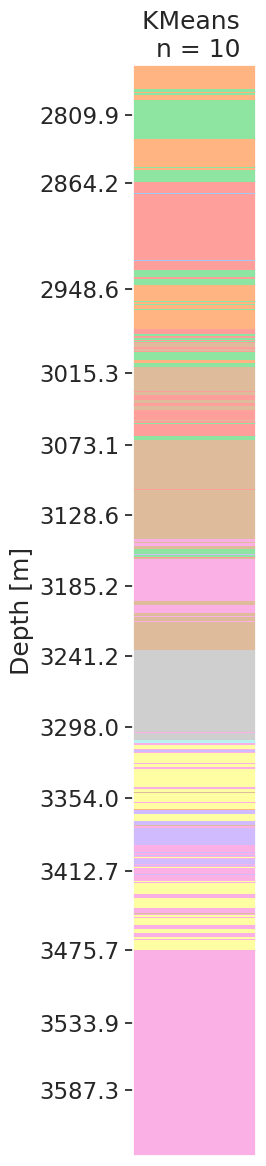

In [48]:
K5_graph = transformed_data.copy()
K5_graph['x'] = 1
sns.set_style("white")
sns.set(font_scale = 1.5)
plt.rcParams['xtick.major.size'] = 200
plt.rcParams['xtick.major.width'] = 40
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.figure(figsize=(3,12))
ax = sns.scatterplot(data=K5_graph, x='x', y='DEPTH', hue='K10_name', marker='s', s=50000, edgecolor='None', palette='pastel')
plt.tick_params(bottom=False, labelbottom=False)
plt.yticks(K5_graph['DEPTH'][::500])
plt.legend([],[], frameon=False)
plt.ylabel("Depth [m]")
plt.xlabel('')
plt.title("KMeans \n n = 10")
ax.invert_yaxis()
plt.tight_layout()
plt.rcParams.update({})

The facies strip plot effectively visualizes the mathematical partitioning of the well into 10 distinct electrofacies. Each color represents a group of rocks with similar physical properties. While $n=10$ provides high resolution, it may be over-segmenting the data (splitting similar rocks into too many categories).

In [49]:
def score(n_clusters, data, cols):
    model = KMeans(n_clusters=n_clusters, max_iter=300, random_state=1234)
    X = transformed_data[cols]
    y = model.fit_predict(X)
    SSE = model.inertia_
    Silhouette = metrics.silhouette_score(X, y)
    CHS = metrics.calinski_harabasz_score(X, y)
    DBS = metrics.davies_bouldin_score(X, y)
    return {'SSE':SSE, 'Silhouette': Silhouette, 'Calinski_Harabasz': CHS, 'Davies_Bouldin':DBS, 'model':model}

In [50]:
df_cluster_scorer = pd.DataFrame()
df_cluster_scorer['n_clusters'] = list(range(2, 21))
df_cluster_scorer

,n_clusters
0,2
1,3
2,4
3,5
4,6
5,7
6,8
7,9
8,10
9,11


In [51]:
from sklearn import metrics

df_cluster_scorer['SSE'],df_cluster_scorer['Silhouette'],\
df_cluster_scorer['Calinski_Harabasz'], df_cluster_scorer['Davies_Bouldin'],\
df_cluster_scorer['model'] = zip(*df_cluster_scorer['n_clusters'].map(lambda row: score(row, transformed_data, cols).values()))

df_cluster_scorer

,n_clusters,SSE,Silhouette,Calinski_Harabasz,Davies_Bouldin,model
0,2,22239.334843,0.400871,5066.094630,1.008036,"KMeans(n_clusters=2, random_state=1234)"
1,3,17714.774445,0.360296,4024.430453,0.953045,"KMeans(n_clusters=3, random_state=1234)"
2,4,12443.160398,0.378488,4752.944063,0.941042,"KMeans(n_clusters=4, random_state=1234)"
3,5,9581.565147,0.396143,5122.370456,0.827744,"KMeans(n_clusters=5, random_state=1234)"
4,6,8406.763714,0.363733,4854.666961,0.944934,"KMeans(n_clusters=6, random_state=1234)"
5,7,7391.868658,0.365586,4751.666840,0.840729,"KMeans(n_clusters=7, random_state=1234)"
6,8,7116.625406,0.350367,4266.175461,1.005628,KMeans(random_state=1234)
7,9,6474.933699,0.358444,4184.108138,0.954318,"KMeans(n_clusters=9, random_state=1234)"
8,10,5459.549264,0.364801,4546.807578,0.883447,"KMeans(n_clusters=10, random_state=1234)"
9,11,5055.156279,0.345695,4471.658521,0.910427,"KMeans(n_clusters=11, random_state=1234)"


<Figure size 800x600 with 0 Axes>

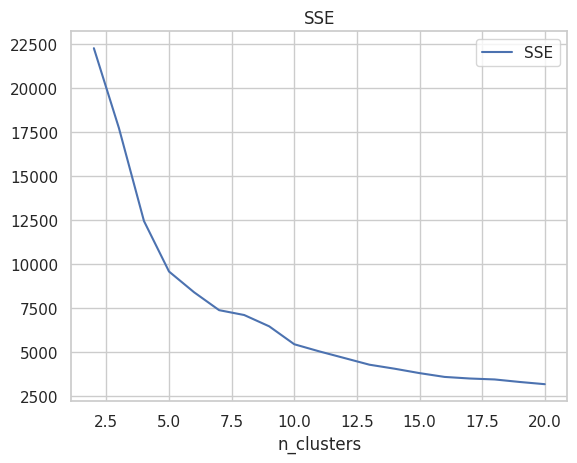

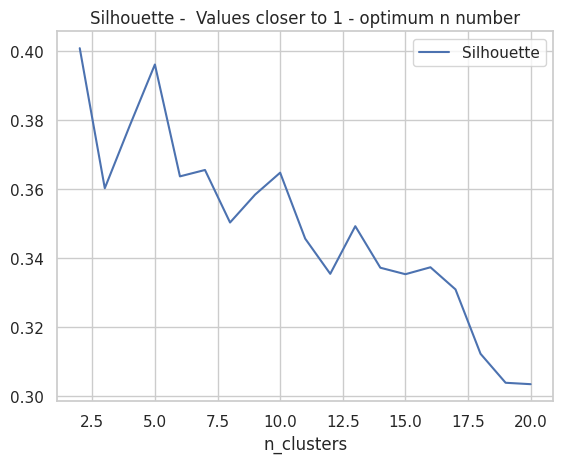

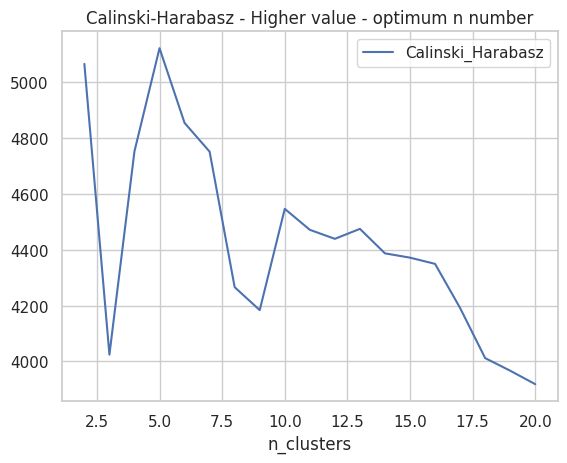

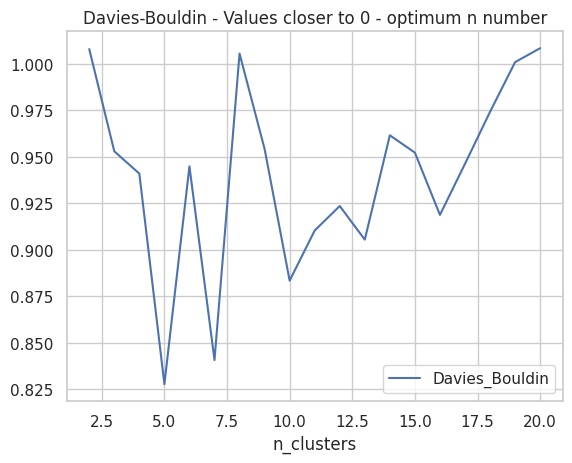

In [52]:
plt.rcParams.update({})
sns.set()
sns.set_style("whitegrid")

fig = plt.figure(figsize=(8, 6))

# Plot each graph on its own axis
df_cluster_scorer.plot.line(x='n_clusters', y='SSE', title="SSE")
df_cluster_scorer.plot.line(x='n_clusters', y='Silhouette', title="Silhouette -  Values closer to 1 - optimum n number")
df_cluster_scorer.plot.line(x='n_clusters', y='Calinski_Harabasz', title="Calinski-Harabasz - Higher value - optimum n number")
df_cluster_scorer.plot.line(x='n_clusters', y='Davies_Bouldin', title="Davies-Bouldin - Values closer to 0 - optimum n number")

#plt.tight_layout()
plt.show()

## Choose optimum number of clusters and predict!

Read about metrics here: https://www.mdpi.com/1996-1073/16/1/493 and describe why did you pick this number

In [53]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

def find_optimal_facies(data, feature_cols, max_n=15):
    """
    Automatically selects the optimal number of clusters based on
    three metrics: Silhouette, Calinski-Harabasz, and Davies-Bouldin.
    """
    X = data[feature_cols]
    results = []

    print(f"Analyzing metrics for n ranging from 2 to {max_n}...")

    for n in range(2, max_n + 1):
        # Initializing KMeans with fixed random state for reproducibility
        model = KMeans(n_clusters=n, n_init=10, random_state=1234)
        labels = model.fit_predict(X)

        # Calculating statistical validity metrics
        sil = metrics.silhouette_score(X, labels)
        chs = metrics.calinski_harabasz_score(X, labels)
        dbs = metrics.davies_bouldin_score(X, labels)

        results.append({'n': n, 'Sil': sil, 'CH': chs, 'DB': dbs})

    df_m = pd.DataFrame(results)

    # SELECTION LOGIC:
    # 1. Find n with highest Silhouette (ignoring n=2 as it's often too simple for geology)
    best_sil = df_m[df_m['n'] > 2].loc[df_m[df_m['n'] > 2]['Sil'].idxmax(), 'n']

    # 2. Find n with highest Calinski-Harabasz score
    best_ch = df_m.loc[df_m['CH'].idxmax(), 'n']

    # 3. Find n with lowest Davies-Bouldin index
    best_db = df_m.loc[df_m['DB'].idxmin(), 'n']

    # Choose the consensus - the most frequent value (mode) among the three metrics
    final_n = pd.Series([best_sil, best_ch, best_db]).mode()[0]

    print(f"--- AUTOMATION RESULTS ---")
    print(f"Best Silhouette (n>2): {best_sil}")
    print(f"Best Calinski-Harabasz: {best_ch}")
    print(f"Best Davies-Bouldin: {best_db}")
    print(f"Recommended number of clusters (Consensus): {final_n}")

    return int(final_n)

# Define the geophysical logs used for clustering
cols = ['NPHI', 'RHOB', 'GR', 'RT', 'PEF', 'CALI', 'DT']

# Run the automated selection function
opt_n = find_optimal_facies(transformed_data, cols)

print(f"The optimal number of clusters: {opt_n}")

# Fit the final model using the optimal number of clusters
final_model = KMeans(n_clusters=opt_n, n_init=10, random_state=1234)
transformed_data['Facies'] = final_model.fit_predict(transformed_data[cols])
transformed_data['Facies_Name'] = "Facies " + (transformed_data['Facies'] + 1).astype(str)

Analyzing metrics for n ranging from 2 to 15...
--- AUTOMATION RESULTS ---
Best Silhouette (n>2): 5
Best Calinski-Harabasz: 5
Best Davies-Bouldin: 5
Recommended number of clusters (Consensus): 5
The optimal number of clusters: 5


Choosing the Optimum Number of Clusters: $n = 5$. The automated script selected $n=5$ because it maximizes cluster density (Calinski-Harabasz) while minimizing overlap (Davies-Bouldin).  

Justification based on metrics:  
- Silhouette Score: This is a key measure of cluster separation (higher is better). For $n=5$, we see a score of 0.3961, which is the highest value after $n=2$. While $n=2$ has a higher score, it is usually too simplistic for geological data as it would only distinguish between "reservoir" and "non-reservoir" rocks.  
- Calinski-Harabasz Index: This index measures the ratio of between-cluster dispersion to within-cluster dispersion (higher is better). The peak occurs exactly at $n=5$ (5122.37), indicating the most well-defined groups.  
- Davies-Bouldin Index: This measures the average similarity between clusters (lower/closer to 0 is better). At $n=5$, we achieve the lowest score (0.8277) in the entire dataset, confirming that the clusters are most unique and have the least overlap.  
- Elbow Method (SSE): At $n=5$, there is a clear "inflection point" or elbow in the curve. Increasing the number of clusters further (e.g., to 10 or 15) only yields marginal improvements in error reduction, suggesting that $n=5$ is the "sweet spot" to avoid overfitting.

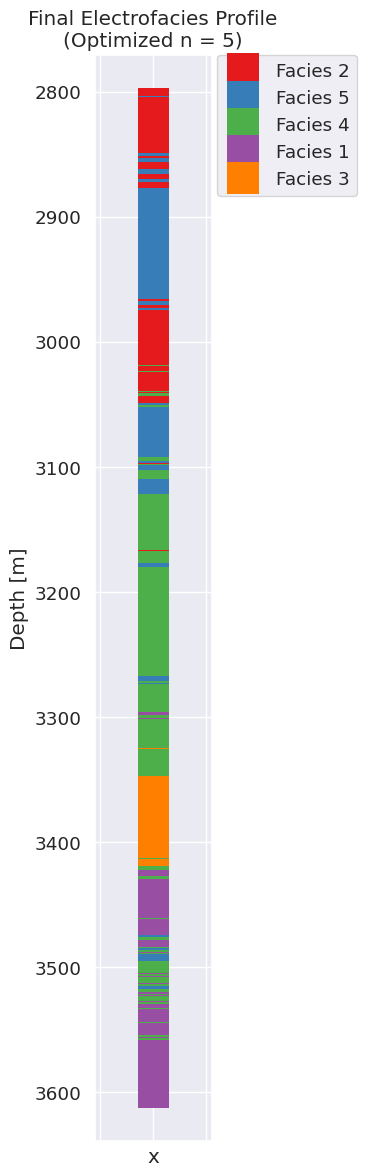

In [54]:
# Create a copy for visualization purposes
facies_plot_df = transformed_data.copy()
facies_plot_df['x'] = 1  # Constant value for the X-axis to create a vertical strip

# Set plot aesthetics
sns.set_style("white")
sns.set(font_scale=1.2)
plt.figure(figsize=(4, 12))

# Generate the vertical facies strip
# Using 'Set1' palette for clear visual contrast between the 5 facies
ax = sns.scatterplot(data=facies_plot_df, x='x', y='DEPTH', hue='Facies_Name',
                     marker='s', s=500, edgecolor='None', palette='Set1')

# Formatting the axes and legend
plt.tick_params(bottom=False, labelbottom=False)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.ylabel("Depth [m]")
plt.title(f"Final Electrofacies Profile\n(Optimized n = {opt_n})")

# Invert Y-axis so depth increases downwards (Standard Well Log View)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Compare your results with the stratigrapy
https://www.researchgate.net/publication/332441275_Estimation_of_Pore_Pressure_and_Fracture_Gradient_in_Volve_Field_Norwegian_North_Sea

Unfortunately, it was not possible to clearly compare the results due to the lack of access to the entire article.